Research question 

To what extent are rural communities able to achieve “green growth” in British Columbia, as measured by a decoupling of growth in wellbeing from the growth in GHG emissions? 


Scope 

Timeframe: 2006 (extrapolated) – 2021 

Emissions scope: CO2e for utilities of residential and small and medium indistry, and on-road transportation

In [130]:
#import libraries
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [131]:
#load the community emissions dataset as csv file

utility_emissions = pd.read_csv('../data/raw/bc_utilities_energy_and_emissions.csv')

#replace W's from emissions in wood with 0
utility_emissions['EMISSIONS NET IMPORTS (TCO2e)'] = utility_emissions['EMISSIONS NET IMPORTS (TCO2e)'].replace('W', 0)

# Display the first few rows of the utility emissions dataset
utility_emissions.head()

,YEAR,SOURCE,Data Source ID,ORG_UNIT,ORG_NAME,ORG_PART,ENERGY_TYPE,ENERGY_UNIT,SUB_SECTOR,CONSUMPTION_TOTAL,CONNECTION_TOTAL,EMISSIONS NET IMPORTS (TCO2e),Unnamed: 12
0,2022,BC Hydro,11080,5909052,Abbotsford,1005909,ELEC,kWh,Res,"538,127,236","48,760","6,188",NaN
1,2022,BC Hydro,11080,1005923,Alberni-Clayoquot,9000000,ELEC,kWh,Res,"226,116,611","17,311","2,600",NaN
2,2022,BC Hydro,11080,2005923,Alberni-Clayoquot Unincorporated Areas,1005923,ELEC,kWh,Res,"79,348,847","5,601",912,NaN
3,2022,BC Hydro,11080,5943008,Alert Bay,1005943,ELEC,kWh,Res,"3,775,260",275,43,NaN
4,2022,BC Hydro,11080,5915038,Anmore,1005915,ELEC,kWh,Res,"14,323,873",773,165,NaN


In [132]:
# load the transportation emissions dataset as csv file
transportation_emissions = pd.read_csv('../data/raw/bc_on_road_transportation_data_at_the_community_level.csv')
transportation_emissions.head()


/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_15366/1375076493.py:2: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  transportation_emissions = pd.read_csv('../data/raw/bc_on_road_transportation_data_at_the_community_level.csv')


,ORG_UNIT,ORG_NAME,ORG_PART,Year,Vehicle Type,Fuel Type,Vehicle Fuel Category,Policy Years Earned,Vehicle Kilometres Travelled,Letres Equivalents,Emissions tCO2e,Unnamed: 11
0,5909052,Abbotsford,1005909,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,1.00,11734.493600,5890.715786,8.010833,NaN
1,5915038,Anmore,1005915,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.89,9240.491799,4638.726883,6.308712,NaN
2,5933019,Ashcroft,1005933,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.76,7890.757042,3961.160035,5.388842,NaN
3,5915036,Belcarra,1005915,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.00,0.000000,0.000000,0.000000,NaN
4,2005951,Bulkley-Nechako Unincorporated Areas,1005951,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.11,1142.083256,573.325795,0.778630,NaN


In [133]:
#list of regional districts 
bc_regional_districts = [
    "Alberni-Clayoquot",
    "Bulkley-Nechako",
    "Capital",
    "Cariboo",
    "Central Coast",
    "Central Kootenay",
    "Central Okanagan",
    "Columbia-Shuswap",
    "Comox Valley",
    "Cowichan Valley",
    "East Kootenay",
    "Fraser Valley",
    "Fraser-Fort George",
    "Islands Trust",
    "Kitimat-Stikine",
    "Kootenay Boundary",
    "Metro-Vancouver",
    "Mount Waddington",
    "Nanaimo RD",
    "North Okanagan",
    "Northern Rockies RD",
    "Okanagan-Similkameen",
    "Peace River",
    "qathet",
    "Skeena-Queen Charlotte",
    "Squamish-Lillooet",
    "Strathcona",
    "Sunshine Coast",
    "Thompson-Nicola"
]
#list of unincorporated areas
list_of_unincorporated_areas = [
    "Alberni-Clayoquot Unincorporated Areas",
    "Bulkley-Nechako Unincorporated Areas",
    "Capital Unincorporated Areas",
    "Cariboo Unincorporated Areas",
    "Central Coast Unincorporated Areas",
    "Central Kootenay Unincorporated Areas",
    "Central Okanagan Unincorporated Areas",
    "Columbia-Shuswap Unincorporated Areas",
    "Comox Valley Unincorporated Areas",
    "Cowichan Valley Unincorporated Areas",
    "East Kootenay Unincorporated Areas",
    "Fraser Valley Unincorporated Areas",
    "Fraser-Fort George Unincorporated Areas",
    "Islands Trust Unincorporated Areas",
    "Kitimat-Stikine Unincorporated Areas",
    "Stikine",
    "Kootenay Boundary Unincorporated Areas",
    "Metro-Vancouver Unincorporated Areas",
    "Mount Waddington Unincorporated Areas",
    "Nanaimo Unincorporated Areas",
    "Skeena-Queen Charlotte Unincorporated Areas",
    "North Okanagan Unincorporated Areas",
    "Northern Rockies Unincorporated Areas",
    "Okanagan-Similkameen Unincorporated Areas",
    "Peace River Unincorporated Areas",
    "Powell River Unincorporated Areas",
    "qathet Unincorporated Areas",
    "Squamish-Lillooet Unincorporated Areas",
    "Stikine Unincorporated Areas",
    "Sunshine Coast Unincorporated Areas",
    "Strathcona Unincorporated Areas",
    "Thompson-Nicola Unincorporated Areas"
]
province = ["British Columbia"]

Indigenous= ["Sechelt IGD"]

outliers = ["Northern Rockies Regional Municipality","Northern Rockies RD", "Northern Rockies"]


#list of years
years_transportation_co2 = [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
years_utility_co2 = [2007, 2010, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
years_industrial_co2 = [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
#years_waste_co2 = [2007, 2010, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]





In [134]:
# load the industrial emissions dataset as csv file
industrial_emissions = pd.read_csv('../data/raw/bc_industrial_facility_public_report_summary_raw_data.csv')
industrial_emissions.head()


,Reporting Year,Company Name,Facility Name,Primary Activity NAICS Code & Description,Facility Type,Latitude,Longitude,Regional District,CO2 fossil combustion,CO2 biomass combustion,...,SF6 FVPW,CO2 fossil total,CO2 biomass total,CH4 total,N2O total,HFCs total,PFCs total,SF6 total,Grand total (tCO2e),Verification Body
0,2012.0,Aitken Creek Gas Storage ULC,Aitken Creek Gas Storage ULC,211110--Oil and gas extraction (except oil sands),LFO,56.96,-121.920,British Columbia,"44,706.60",NaN,...,NaN,"44,710.58",NaN,"7,396.69",181.26,NaN,NaN,NaN,"52,288.53",SNC Lavalin Environment
1,2012.0,Alliance Pipeline Ltd.,"BC Aggregated Facilities (E<= 1,000t CO2e each)",486210--Pipeline Transportation of Natural Gas,Other Facilities,56.18,-120.607,British Columbia,258.37,NaN,...,NaN,259.30,NaN,"1,127.15",1.25,NaN,NaN,NaN,"1,387.70",Refer to LFO Report
2,2012.0,Alliance Pipeline Ltd.,BC Pipeline System (LFO),486210--Pipeline Transportation of Natural Gas,LFO,56.18,-120.607,British Columbia,"22,877.11",NaN,...,NaN,"22,878.66",NaN,"2,939.10",153.17,NaN,NaN,NaN,"25,970.92",KPMG Performance Registrar Inc.
3,2012.0,Alliance Pipeline Ltd.,Taylor Compressor Station,486210--Pipeline Transportation of Natural Gas,Large Facility,56.18,-120.607,British Columbia,"22,618.74",NaN,...,NaN,"22,619.36",NaN,"1,811.95",151.92,NaN,NaN,NaN,"24,583.23",Refer to LFO Report
4,2012.0,AltaGas Ltd.,ALA BC L_c,211110--Oil and gas extraction (except oil sands),Other Facilities,56.15,-120.670,British Columbia,88.93,NaN,...,NaN,90.87,NaN,"4,180.91",NaN,NaN,NaN,NaN,"4,271.78",Refer to LFO Report


In [135]:
#list of regional districts including typos in datasets
bc_regional_districts = [
    "Alberni-Clayoquot",
    "Bulkley-Nechako",
    "Capital",
    "Cariboo",
    "Central Coast",
    "Central Kootenay",
    "Central Okanagan",
    "Columbia-Shuswap",
    "Comox Valley",
    "Cowichan Valley",
    "East Kootenay",
    "Fraser Valley",
    "Fraser-Fort George",
    "Greater Vancouver",
    "Islands Trust",
    "Kitimat-Stikine",
    "Kootenay Boundary",
    "Metro-Vancouver",
    "Mount Waddington",
    "Nanaimo RD",
    "North Okanagan",
    "Northern Rockies RD",
    "Okanagan-Similkameen",
    "Peace River",
    "qathet",
    "Skeena-Queen Charlotte",
    "Squamish-Lillooet",
    "Stikine",
    "Sitkine",
    "Strathcona",
    "Sunshine Coast",
    "Thompson-Nicola"
]
#list of unincorporated areas
list_of_unincorporated_areas = [
    "Alberni-Clayoquot Unincorporated Areas",
    "Bulkley-Nechako Unincorporated Areas",
    "Capital Unincorporated Areas",
    "Cariboo Unincorporated Areas",
    "Central Coast Unincorporated Areas",
    "Central Kootenay Unincorporated Areas",
    "Central Okanagan Unincorporated Areas",
    "Columbia-Shuswap Unincorporated Areas",
    "Comox Valley Unincorporated Areas",
    "Comox Unincorporated Areas",
    "Cowichan Valley Unincorporated Areas",
    "East Kootenay Unincorporated Areas",
    "Fraser Valley Unincorporated Areas",
    "Fraser-Fort George Unincorporated Areas",
    "Greater Vancouver Unincorporated Areas",
    "Islands Trust Unincorporated Areas",
    "Kitimat-Stikine Unincorporated Areas",
    "Kootenay Boundary Unincorporated Areas",
    "Metro-Vancouver Unincorporated Areas",
    "Mount Waddington Unincorporated Areas",
    "Nanaimo Unincorporated Areas",
    "Skeena-Queen Charlotte Unincorporated Areas",
    "North Okanagan Unincorporated Areas",
    "Northern Rockies Unincorporated Areas",
    "Okanagan-Similkameen Unincorporated Areas",
    "Peace River Unincorporated Areas",
    "Powell River Unincorporated Areas",
    "qathet Unincorporated Areas",
    "Squamish-Lillooet Unincorporated Areas",
    "Stikine Unincorporated Areas",
    "Sitkine Unincorporated Areas",
    "Sunshine Coast Unincorporated Areas",
    "Strathcona Unincorporated Areas",
    "Thompson-Nicola Unincorporated Areas"
]
province = ["British Columbia"]

Indigenous= ["Sechelt IGD", "Sechelt Ind Gov Dist (Part-Powell River)"]

outliers = ["Northern Rockies Regional Municipality","Northern Rockies RD", "Northern Rockies"]

#list of years
years_transportation_co2 = [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
years_buildings_co2 = [2007, 2010, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
years_waste_co2 = [2007, 2010, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

In [136]:
#select municipalities from the utility emissions dataset (by excluding regional districts and unincorporated areas)
mask = ~utility_emissions['ORG_NAME'].isin(list_of_unincorporated_areas + bc_regional_districts + province + Indigenous + outliers)
utility_df = utility_emissions[mask]
utility_df.head()


,YEAR,SOURCE,Data Source ID,ORG_UNIT,ORG_NAME,ORG_PART,ENERGY_TYPE,ENERGY_UNIT,SUB_SECTOR,CONSUMPTION_TOTAL,CONNECTION_TOTAL,EMISSIONS NET IMPORTS (TCO2e),Unnamed: 12
0,2022,BC Hydro,11080,5909052,Abbotsford,1005909,ELEC,kWh,Res,"538,127,236","48,760","6,188",NaN
3,2022,BC Hydro,11080,5943008,Alert Bay,1005943,ELEC,kWh,Res,"3,775,260",275,43,NaN
4,2022,BC Hydro,11080,5915038,Anmore,1005915,ELEC,kWh,Res,"14,323,873",773,165,NaN
5,2022,BC Hydro,11080,5937028,Armstrong,1005937,ELEC,kWh,Res,"21,935,314","2,408",252,NaN
6,2022,BC Hydro,11080,5933019,Ashcroft,1005933,ELEC,kWh,Res,"7,649,214",940,88,NaN


In [137]:
#save the utility_df to a csv file in the data/processed folder
utility_df.to_csv(os.path.join('..','data','processed','municipalities_energy_and_emissions.csv'), index=False)

In [138]:
#select municipalities from the utility emissions dataset (by excluding regional districts and unincorporated areas)
mask = ~transportation_emissions['ORG_NAME'].isin(list_of_unincorporated_areas + bc_regional_districts + province + Indigenous + outliers)
transportation_df = transportation_emissions[mask]

#change names of communities to match the utility_df
# Greater Vancouver -> Metro Vancouver
# Sun Peaks Mountain -> Sun Peaks Mountain Resort
# Sechelt District Municipality -> Sechelt

transportation_df['ORG_NAME'] = transportation_df['ORG_NAME'].replace({
    "Greater Vancouver": "Metro Vancouver",
    "Sun Peaks Mountain": "Sun Peaks Mountain Resort",
    "Sechelt District Municipality": "Sechelt"
})

transportation_df.head()


/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_15366/556069077.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transportation_df['ORG_NAME'] = transportation_df['ORG_NAME'].replace({


,ORG_UNIT,ORG_NAME,ORG_PART,Year,Vehicle Type,Fuel Type,Vehicle Fuel Category,Policy Years Earned,Vehicle Kilometres Travelled,Letres Equivalents,Emissions tCO2e,Unnamed: 11
0,5909052,Abbotsford,1005909,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,1.00,11734.493600,5890.715786,8.010833,NaN
1,5915038,Anmore,1005915,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.89,9240.491799,4638.726883,6.308712,NaN
2,5933019,Ashcroft,1005933,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.76,7890.757042,3961.160035,5.388842,NaN
3,5915036,Belcarra,1005915,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.00,0.000000,0.000000,0.000000,NaN
5,5915025,Burnaby,1005915,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,9.62,112885.828400,56668.685860,77.069859,NaN


In [139]:
transportation_df.to_csv(os.path.join('..','data','processed','municipalities_energy_and_emissions.csv'), index=False)

In [140]:
# Option 1: If you want to align 2011 CWB data with 2012 emissions (assuming emissions in 2011 ≈ 2012)
# Option 2: Restrict analysis to years where both CWB and emissions data are available (2016 and 2021)

# Example: Filter emissions data for 2016, and 2021
utility_emissions_years = [2016, 2021]
utility_emissions_selected = utility_df[utility_df['YEAR'].isin(utility_emissions_years)]

# Display the number of records for each year
print(utility_emissions_selected['YEAR'].value_counts().sort_index())
utility_emissions_selected.head()
# now can now merge emissions_selected with the corresponding CWB datasets for your analysis


YEAR
2016    1058
2021    1197
Name: count, dtype: int64


,YEAR,SOURCE,Data Source ID,ORG_UNIT,ORG_NAME,ORG_PART,ENERGY_TYPE,ENERGY_UNIT,SUB_SECTOR,CONSUMPTION_TOTAL,CONNECTION_TOTAL,EMISSIONS NET IMPORTS (TCO2e),Unnamed: 12
592,2021,BC Hydro,10080,5909052,Abbotsford,1005909,ELEC,kWh,Res,"545,291,693","48,284","5,289",NaN
595,2021,BC Hydro,10080,5943008,Alert Bay,1005943,ELEC,kWh,Res,"3,699,136",274,36,NaN
596,2021,BC Hydro,10080,5915038,Anmore,1005915,ELEC,kWh,Res,"14,346,401",768,139,NaN
597,2021,BC Hydro,10080,5937028,Armstrong,1005937,ELEC,kWh,Res,"22,018,806","2,403",214,NaN
598,2021,BC Hydro,10080,5933019,Ashcroft,1005933,ELEC,kWh,Res,"7,648,143",939,74,NaN


In [141]:
# Option 1: If you want to align 2011 CWB data with 2012 emissions (assuming emissions in 2011 ≈ 2012)
# Option 2: Restrict analysis to years where both CWB and emissions data are available (2016 and 2021)

# Example: Filter emissions data for 2016, and 2021
transportation_emissions_years = [2016, 2021]
transportation_emissions_selected = transportation_df[transportation_df['Year'].isin(transportation_emissions_years)]

# Display the number of records for each year
print(transportation_emissions_selected['Year'].value_counts().sort_index())
transportation_emissions_selected.head()
# now can now merge emissions_selected with the corresponding CWB datasets for your analysis

Year
2016    6067
2021    7382
Name: count, dtype: int64


,ORG_UNIT,ORG_NAME,ORG_PART,Year,Vehicle Type,Fuel Type,Vehicle Fuel Category,Policy Years Earned,Vehicle Kilometres Travelled,Letres Equivalents,Emissions tCO2e,Unnamed: 11
115623,5915025,Burnaby,1005915,2016,Bus,CH,Heavy-Duty Gasoline Vehicles,5.70,78763.52220,39539.288150,51.005987,NaN
115624,5924034,Campbell River,1005924,2016,Bus,CH,Heavy-Duty Gasoline Vehicles,1.14,17606.79468,8838.610931,11.399310,NaN
115626,5909020,Chilliwack,1005909,2016,Bus,CH,Heavy-Duty Gasoline Vehicles,2.28,31505.40888,15815.715260,20.401317,NaN
115628,5915034,Coquitlam,1005915,2016,Bus,CH,Heavy-Duty Gasoline Vehicles,1.14,15752.70444,7907.857629,10.203352,NaN
115629,5901022,Cranbrook,1005901,2016,Bus,CH,Heavy-Duty Gasoline Vehicles,1.14,17606.79468,8838.610931,11.399310,NaN


In [142]:
#for each year and each community, calculate the total emissions for that community by summing the emissions for values in the SUB_SECTOR column into one (sum Res, CSMI and MIXED)

# Remove commas from the values, then convert to numeric
utility_emissions_selected['EMISSIONS NET IMPORTS (TCO2e)'] = utility_emissions_selected['EMISSIONS NET IMPORTS (TCO2e)'].astype(str).str.replace(',', '')
#remove 'W' from the values and convert to numeric, filling NaN with 0
utility_emissions_selected['EMISSIONS NET IMPORTS (TCO2e)'] = pd.to_numeric(utility_emissions_selected['EMISSIONS NET IMPORTS (TCO2e)'], errors='coerce').fillna(0)

# Now group by 'YEAR' and 'ORG_NAME' and sum the emissions
total_utility_emissions = utility_emissions_selected.groupby(['YEAR', 'ORG_NAME'])['EMISSIONS NET IMPORTS (TCO2e)'].sum().reset_index()

#save to csv file in the data/processed folder
total_utility_emissions.to_csv(os.path.join('..','data','processed','total_utility_emissions.csv'), index=False)

/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_15366/3339896199.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  utility_emissions_selected['EMISSIONS NET IMPORTS (TCO2e)'] = utility_emissions_selected['EMISSIONS NET IMPORTS (TCO2e)'].astype(str).str.replace(',', '')
/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_15366/3339896199.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  utility_emissions_selected['EMISSIONS NET IMPORTS (TCO2e)'] = pd.to_numeric(utility_emissions_selecte

In [143]:
#print all unique org-names in the utilties dataframe
print("Unique organizations in utility emissions:")
print(total_utility_emissions['ORG_NAME'].unique())

Unique organizations in utility emissions:
['Abbotsford' 'Alert Bay' 'Anmore' 'Armstrong' 'Ashcroft' 'Barriere'
 'Belcarra' 'Bowen Island' 'Burnaby' 'Burns Lake' 'Cache Creek'
 'Campbell River' 'Canal Flats' 'Castlegar' 'Central Saanich' 'Chase'
 'Chetwynd' 'Chilliwack' 'Clearwater' 'Clinton' 'Coldstream' 'Colwood'
 'Comox' 'Coquitlam' 'Courtenay' 'Cranbrook' 'Creston' 'Cumberland'
 'Dawson Creek' 'Delta' 'Duncan' 'Elkford' 'Enderby' 'Esquimalt' 'Fernie'
 'Fort St. James' 'Fort St. John' 'Fraser Lake' 'Fruitvale' 'Gibsons'
 'Gold River' 'Golden' 'Grand Forks' 'Granisle' 'Greenwood'
 'Harrison Hot Springs' 'Hazelton' 'Highlands' 'Hope' 'Houston'
 "Hudson's Hope" 'Invermere' 'Kamloops' 'Kaslo' 'Kelowna' 'Kent'
 'Keremeos' 'Kimberley' 'Kitimat' 'Ladysmith' 'Lake Country'
 'Lake Cowichan' 'Langford' 'Langley City' 'Langley Township' 'Lantzville'
 'Lillooet' 'Lions Bay' 'Logan Lake' 'Lumby' 'Lytton' 'Mackenzie'
 'Maple Ridge' 'Masset' 'McBride' 'Merritt' 'Metchosin' 'Midway' 'Mission'
 'Mon

In [144]:
print ("\nTotal utility emissions for each community:")
# Display the total utility emissions for each community
print(total_utility_emissions)


Total utility emissions for each community:
     YEAR        ORG_NAME  EMISSIONS NET IMPORTS (TCO2e)
0    2016      Abbotsford                         356917
1    2016       Alert Bay                            408
2    2016          Anmore                           4551
3    2016       Armstrong                          10115
4    2016        Ashcroft                          12333
..    ...             ...                            ...
313  2021  West Vancouver                         138130
314  2021        Whistler                          54439
315  2021      White Rock                          41195
316  2021   Williams Lake                          88586
317  2021        Zeballos                            145

[318 rows x 3 columns]


In [145]:
#for each year and each community, calculate the total emissions for that community by summing the emissions for values in all vehicle fuel categories

# Group by 'YEAR' and 'ORG_NAME' and sum the emissions
total_transportation_emissions = transportation_emissions_selected.groupby(['Year', 'ORG_NAME'])['Emissions tCO2e'].sum().reset_index()

#save to csv file in the data/processed folder
total_transportation_emissions.to_csv(os.path.join('..','data','processed','total_transportation_emissions.csv'), index=False)

In [146]:
print("Unique organizations in total_emissions:")
print(total_transportation_emissions['ORG_NAME'].unique())

Unique organizations in total_emissions:
['Abbotsford' 'Alert Bay' 'Anmore' 'Armstrong' 'Ashcroft' 'Barriere'
 'Belcarra' 'Bowen Island' 'Burnaby' 'Burns Lake' 'Cache Creek'
 'Campbell River' 'Canal Flats' 'Castlegar' 'Central Saanich' 'Chase'
 'Chetwynd' 'Chilliwack' 'Clearwater' 'Clinton' 'Coldstream' 'Colwood'
 'Comox' 'Coquitlam' 'Courtenay' 'Cranbrook' 'Creston' 'Cumberland'
 'Dawson Creek' 'Delta' 'Duncan' 'Elkford' 'Enderby' 'Esquimalt' 'Fernie'
 'Fort St. James' 'Fort St. John' 'Fraser Lake' 'Fruitvale' 'Gibsons'
 'Gold River' 'Golden' 'Grand Forks' 'Granisle' 'Greenwood'
 'Harrison Hot Springs' 'Hazelton' 'Highlands' 'Hope' 'Houston'
 "Hudson's Hope" 'Invermere' 'Kamloops' 'Kaslo' 'Kelowna' 'Kent'
 'Keremeos' 'Kimberley' 'Kitimat' 'Ladysmith' 'Lake Country'
 'Lake Cowichan' 'Langford' 'Langley City' 'Langley Township' 'Lantzville'
 'Lillooet' 'Lions Bay' 'Logan Lake' 'Lumby' 'Lytton' 'Mackenzie'
 'Maple Ridge' 'Masset' 'McBride' 'Merritt' 'Metchosin' 'Midway' 'Mission'
 'Montr

In [147]:
print ("\nTotal transportation emissions for each community:")
# Display the total transportation emissions for each community
#total_emissions.head()
print(total_transportation_emissions)


Total transportation emissions for each community:
     Year        ORG_NAME  Emissions tCO2e
0    2016      Abbotsford    569263.582000
1    2016       Alert Bay      1194.705601
2    2016          Anmore      7421.111512
3    2016       Armstrong     26823.412983
4    2016        Ashcroft      6743.397754
..    ...             ...              ...
313  2021  West Vancouver     83139.159580
314  2021        Whistler     42823.052452
315  2021      White Rock     47615.711657
316  2021   Williams Lake     61881.430213
317  2021        Zeballos       272.908979

[318 rows x 3 columns]


In [ ]:
transportation_emissions_communities_list = set(total_transportation_emissions['ORG_NAME'])
utility_emissions_communities_list = set(total_utility_emissions['ORG_NAME'])
# Find communities that are in transportation emissions but not in utility emissions
missing_communities = transportation_emissions_communities_list - utility_emissions_communities_list
print("\nCommunities in transportation emissions but not in utility emissions:")
print(missing_communities)


Communities in transportation emissions but not in utility emissions:
set()


In [184]:
#sum emissions from utilities and transportation emissions for each community and year
#first rename Years to YEAR in the transportation emissions dataframe
total_transportation_emissions.rename(columns={'Year': 'YEAR'}, inplace=True)
# Merge the two DataFrames on 'ORG_NAME' and 'YEAR'
merged_emissions = pd.merge(total_utility_emissions, total_transportation_emissions, on=['ORG_NAME', 'YEAR'])
# Rename the columns for clarity
merged_emissions.rename(columns={
    'EMISSIONS NET IMPORTS (TCO2e)': 'Utility Emissions (tCO2e)',
    'Emissions tCO2e': 'Transportation Emissions (tCO2e)'
}, inplace=True)
# Calculate the total emissions by summing the utility and transportation emissions
merged_emissions['Total Emissions (tCO2e)'] = merged_emissions['Utility Emissions (tCO2e)'] + merged_emissions['Transportation Emissions (tCO2e)']
merged_emissions.head()
#save to csv file in the data/processed folder
merged_emissions.to_csv(os.path.join('..','data','processed','total_utility_and_transportation_emissions.csv'), index=False)


In [185]:
# Calculate emissions percent change from 2016 to 2021
# Pivot so you have 2016 and 2021 as columns for each organization
emissions_pivot = merged_emissions.pivot(index='ORG_NAME', columns='YEAR', values='Total Emissions (tCO2e)')

# Calculate percent change
percent_change = ((emissions_pivot[2021] - emissions_pivot[2016]) * 100 / emissions_pivot[2016]).fillna(0)
print("Emissions percent change from 2016 to 2021:")
print(percent_change)

Emissions percent change from 2016 to 2021:
ORG_NAME
Abbotsford        12.928395
Alert Bay        -20.689535
Anmore            -5.225766
Armstrong         -7.483200
Ashcroft          -0.440552
                    ...    
West Vancouver    -5.440064
Whistler          -3.031758
White Rock        -5.420796
Williams Lake     16.711428
Zeballos           3.013906
Length: 159, dtype: float64


In [186]:
emissions_pivot['emissions_percent_change'] = percent_change
emissions_pivot.rename(columns={2016: "2016 EMISSIONS NET IMPORTS TCO2e", 2021: "2021 EMISSIONS NET IMPORTS TCO2e"}, inplace=True)
print(emissions_pivot)
emissions_pivot.to_csv(os.path.join('..','data','processed','municipal_emissions_with_percent_change.csv'))


YEAR            2016 EMISSIONS NET IMPORTS TCO2e  \
ORG_NAME                                           
Abbotsford                         926180.582000   
Alert Bay                            1602.705601   
Anmore                              11972.111512   
Armstrong                           36938.412983   
Ashcroft                            19076.397754   
...                                          ...   
West Vancouver                     233998.845880   
Whistler                           100302.996900   
White Rock                          93900.887221   
Williams Lake                      128922.619913   
Zeballos                              405.682103   

YEAR            2021 EMISSIONS NET IMPORTS TCO2e  emissions_percent_change  
ORG_NAME                                                                    
Abbotsford                          1.045921e+06                 12.928395  
Alert Bay                           1.271113e+03                -20.689535  
Anmore         

In [187]:
#now let's compare community wellbeing changes with emission changes
#open CWB_2021 and CWB_2011 from the data folder/raw
# Load the dataset
cwb_2021 = pd.read_csv(os.path.join('..','data','raw','CWB_2021.csv'),encoding='latin-1')
cwb_2016 = pd.read_csv(os.path.join('..','data','raw','CWB_2016.csv'))
cwb_2011 = pd.read_csv(os.path.join('..','data','raw','CWB_2011.csv'),encoding='latin-1')
# Display the first few rows of each dataset
print("CWB_2021 dataset:")
print(cwb_2021.head())

print("\n CWB_2016_dataset:")
print(cwb_2016.head())

print("\n CWB_2011_dataset:")
print(cwb_2011.head())

CWB_2021 dataset:
   CSD Code 2021             CSD Name 2021  Census Population 2021  \
0        1001101  Division No.  1, Subd. V                    55.0   
1        1001105       Portugal Cove South                    86.0   
2        1001113                 Trepassey                   405.0   
3        1001120               St. Shott's                    55.0   
4        1001124  Division No.  1, Subd. U                  1373.0   

   Income 2021  Education 2021  Housing 2021  Labour Force Activity 2021  \
0          NaN             NaN           NaN                         NaN   
1          NaN             NaN           NaN                         NaN   
2         76.0            48.0          97.0                        70.0   
3          NaN             NaN           NaN                         NaN   
4         81.0            63.0          98.0                        77.0   

   CWB 2021       Community Type 2021  
0       NaN  Non-Indigenous Community  
1      73.0  Non-Indigen

In [188]:
#replace the csd name "north vancouver" that has a csd code 5915046 in column one, to "north vancouver district municipality"
#replace the csd name "north vancouver" that has a csd code 5915051 in column one, to "north vancouver city"

# Replace North Vancouver entries based on CSD codes
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5915046, 'CSD Name 2021'] = 'North Vancouver District'
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5915051, 'CSD Name 2021'] = 'North Vancouver City'

# Verify the changes
print("2021 North Vancouver entries after replacement:")
north_van_2021 = cwb_2021[cwb_2021['CSD Name 2021'].str.contains('North Vancouver', case=False, na=False)]
print(north_van_2021[['CSD Code 2021', 'CSD Name 2021']])

# Replace North Vancouver entries based on CSD codes (adjust column names as needed)
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5915046, 'CSD Name 2016'] = 'North Vancouver District'
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5915051, 'CSD Name 2016'] = 'North Vancouver City'

# Verify the changes
print("2016 North Vancouver entries after replacement:")
north_van_2016 = cwb_2016[cwb_2016['CSD Name 2016'].str.contains('North Vancouver', case=False, na=False)]
print(north_van_2016[['CSD Code 2016', 'CSD Name 2016']])


#rename sun peaks mouintains to sun peaks mountain resort in the cwb data
cwb_2021['CSD Name 2021'] = cwb_2021['CSD Name 2021'].replace('Sun Peaks Mountain', 'Sun Peaks Mountain Resort')
# Verify the changes
print("2021 Sun Peaks entries after replacement:")
sun_peaks_2021 = cwb_2021[cwb_2021['CSD Name 2021'].str.contains('Sun Peaks', case=False, na=False)]
print(sun_peaks_2021[['CSD Code 2021', 'CSD Name 2021']])

cwb_2016['CSD Name 2016'] = cwb_2016['CSD Name 2016'].replace('Sun Peaks Mountain', 'Sun Peaks Mountain Resort')
# Verify the changes
print("2016 Sun Peaks entries after replacement:")
sun_peaks_2016 = cwb_2016[cwb_2016['CSD Name 2016'].str.contains('Sun Peaks', case=False, na=False)]
print(sun_peaks_2016[['CSD Code 2016', 'CSD Name 2016']])


#replace the csd name "langley" that has a csd code 5915001 in column one, to "langley township"
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5915001, 'CSD Name 2021'] = 'Langley Township'
# Verify the changes
print("2021 Langley entries after replacement:")
langley_2021 = cwb_2021[cwb_2021['CSD Name 2021'].str.contains('Langley', case=False, na=False)]
print(langley_2021[['CSD Code 2021', 'CSD Name 2021']])

#replace the csd name "langley" that has a csd code 5915001 in column one, to "langley township"
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5915001, 'CSD Name 2016'] = 'Langley Township'
# Verify the changes
print("2016 Langley entries after replacement:")
langley_2016 = cwb_2016[cwb_2016['CSD Name 2016'].str.contains('Langley', case=False, na=False)]
print(langley_2016[['CSD Code 2016', 'CSD Name 2016']])

#replace the csd name "langley" that has a csd code 5915002 in column one, to "langley city"
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5915002, 'CSD Name 2021'] = 'Langley City'
# Verify the changes
print("2021 Langley entries after replacement:")
langley_2021 = cwb_2021[cwb_2021['CSD Name 2021'].str.contains('Langley', case=False, na=False)]
print(langley_2021[['CSD Code 2021', 'CSD Name 2021']])

#replace the csd name "langley" that has a csd code 5915002 in column one, to "langley city"
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5915002, 'CSD Name 2016'] = 'Langley City'
# Verify the changes
print("2016 Langley entries after replacement:")
langley_2016 = cwb_2016[cwb_2016['CSD Name 2016'].str.contains('Langley', case=False, na=False)]
print(langley_2016[['CSD Code 2016', 'CSD Name 2016']])


2021 North Vancouver entries after replacement:
      CSD Code 2021             CSD Name 2021
4462        5915046  North Vancouver District
4463        5915051      North Vancouver City
2016 North Vancouver entries after replacement:
      CSD Code 2016             CSD Name 2016
4472        5915046  North Vancouver District
4473        5915051      North Vancouver City
2021 Sun Peaks entries after replacement:
      CSD Code 2021              CSD Name 2021
4684        5933045  Sun Peaks Mountain Resort
2016 Sun Peaks entries after replacement:
      CSD Code 2016              CSD Name 2016
4691        5933045  Sun Peaks Mountain Resort
2021 Langley entries after replacement:
      CSD Code 2021     CSD Name 2021
4435        5909856         Langley 2
4447        5915001  Langley Township
4448        5915002           Langley
2016 Langley entries after replacement:
      CSD Code 2016     CSD Name 2016
4457        5915001  Langley Township
4458        5915002           Langley
4494      

In [189]:
#remove cities with the same name in the wellbeing dataset that are not from BC
#correct csd code for Victoria is 5917034
#correct csd code for Richmond is 5915015
#correct csd code for Armstrong is 5937028
#correct csd code for Nelson is 5903015
#correct csd code for Kent is 5909032
#correct csd code for Hope is 5909009
#correct csd code for Esquimalt is 5917040
#correct csd code for Alert Bay is 5943008


# Define the correct BC CSD codes
bc_csd_codes = {
    'Victoria': 5917034,
    'Richmond': 5915015,
    'Armstrong': 5937028,
    'Nelson': 5903015,
    'Kent': 5909032,
    'Hope': 5909009,
    'Esquimalt': 5917040,
    'Alert Bay': 5943008
}

# Remove duplicates by keeping only the correct CSD codes
for city_name, correct_code in bc_csd_codes.items():
    # Remove all rows with this city name that don't have the correct code
    cwb_2021 = cwb_2021[~((cwb_2021['CSD Name 2021'] == city_name) & 
                          (cwb_2021['CSD Code 2021'] != correct_code))]

print("Removed duplicate cities from 2021 dataset")

# Remove duplicates from 2016 dataset (adjust column names)
for city_name, correct_code in bc_csd_codes.items():
    # Remove all rows with this city name that don't have the correct code
    cwb_2016 = cwb_2016[~((cwb_2016['CSD Name 2016'] == city_name) & 
                          (cwb_2016['CSD Code 2016'] != correct_code))]

print("Removed duplicate cities from 2016 dataset")

Removed duplicate cities from 2021 dataset
Removed duplicate cities from 2016 dataset


In [190]:
# Get unique community names from each dataset as a list
emissions_communities = set(emissions_pivot.index)
wellbeing_2021_communities = set(cwb_2021['CSD Name 2021'].dropna())
wellbeing_2016_communities = set(cwb_2016['CSD Name 2016'].dropna())

# Find exact matches (as a list)
exact_matches_2021 = emissions_communities.intersection(wellbeing_2021_communities)
exact_matches_2016 = emissions_communities.intersection(wellbeing_2016_communities)
exact_matches_both = exact_matches_2021.intersection(exact_matches_2016)

print(f"Exact matches with 2021 wellbeing: {len(exact_matches_2021)}")
print(f"Exact matches with 2016 wellbeing: {len(exact_matches_2016)}")
print(f"Exact matches with both years: {len(exact_matches_both)}")

print(f"\nCommunities with matches in both years:")
for community in sorted(list(exact_matches_both))[:10]:  # Show first 10
    print(f"  {community}")

Exact matches with 2021 wellbeing: 159
Exact matches with 2016 wellbeing: 159
Exact matches with both years: 159

Communities with matches in both years:
  Abbotsford
  Alert Bay
  Anmore
  Armstrong
  Ashcroft
  Barriere
  Belcarra
  Bowen Island
  Burnaby
  Burns Lake


In [191]:
# Create new dataframes: Filter wellbeing datasets to only include matched communities in the list of exact matches
matched_cwb_2021 = cwb_2021[cwb_2021['CSD Name 2021'].isin(exact_matches_both)].copy()
matched_cwb_2016 = cwb_2016[cwb_2016['CSD Name 2016'].isin(exact_matches_both)].copy()

print(f"Filtered wellbeing data:")
print(f"  2021: {len(matched_cwb_2021)} communities")
print(f"  2016: {len(matched_cwb_2016)} communities")

# Also filter emissions data to matched communities
matched_emissions = emissions_pivot[emissions_pivot.index.isin(exact_matches_both)].copy()
print(f"  Emissions: {len(matched_emissions)} communities")

Filtered wellbeing data:
  2021: 159 communities
  2016: 159 communities
  Emissions: 159 communities


In [192]:
print("\nMatched communities preview:")
print("Emissions data:")
print(matched_emissions.head())

print("\n2021 Wellbeing data:")
print(matched_cwb_2021.head())

print("\n2016 Wellbeing data:")
print(matched_cwb_2016.head())


Matched communities preview:
Emissions data:
YEAR        2016 EMISSIONS NET IMPORTS TCO2e  \
ORG_NAME                                       
Abbotsford                     926180.582000   
Alert Bay                        1602.705601   
Anmore                          11972.111512   
Armstrong                       36938.412983   
Ashcroft                        19076.397754   

YEAR        2021 EMISSIONS NET IMPORTS TCO2e  emissions_percent_change  
ORG_NAME                                                                
Abbotsford                      1.045921e+06                 12.928395  
Alert Bay                       1.271113e+03                -20.689535  
Anmore                          1.134648e+04                 -5.225766  
Armstrong                       3.417424e+04                 -7.483200  
Ashcroft                        1.899236e+04                 -0.440552  

2021 Wellbeing data:
      CSD Code 2021 CSD Name 2021  Census Population 2021  Income 2021  \
4303      

In [193]:
# Get unmatched communities by subtracting lists
unmatched_emissions = emissions_communities - exact_matches_both

print(f"Total unmatched emissions communities: {len(unmatched_emissions)}")
print("\nAll unmatched emissions communities:")
for community in sorted(list(unmatched_emissions)):
    print(f"  {community}")

Total unmatched emissions communities: 0

All unmatched emissions communities:


In [194]:
# Check for duplicate community names in wellbeing data
print("Duplicate community names in 2021 wellbeing data:")
duplicates_2021 = matched_cwb_2021[matched_cwb_2021.duplicated('CSD Name 2021', keep=False)]['CSD Name 2021'].value_counts()
print(duplicates_2021)

print("\nDuplicate community names in 2016 wellbeing data:")
duplicates_2016 = matched_cwb_2016[matched_cwb_2016.duplicated('CSD Name 2016', keep=False)]['CSD Name 2016'].value_counts()
print(duplicates_2016)

print(f"\nUnique communities in exact_matches_both: {len(exact_matches_both)}")
print(f"Total rows in matched_cwb_2021: {len(matched_cwb_2021)}")
print(f"Total rows in matched_cwb_2016: {len(matched_cwb_2016)}")

Duplicate community names in 2021 wellbeing data:
Series([], Name: count, dtype: int64)

Duplicate community names in 2016 wellbeing data:
Series([], Name: count, dtype: int64)

Unique communities in exact_matches_both: 159
Total rows in matched_cwb_2021: 159
Total rows in matched_cwb_2016: 159


In [195]:
#save mathed dataframes to csv files in the data/processed folder
matched_cwb_2021.to_csv(os.path.join('..', 'data', 'processed', 'matched_cwb_2021.csv'), index=False)
matched_cwb_2016.to_csv(os.path.join('..', 'data', 'processed', 'matched_cwb_2016.csv'), index=False)

In [196]:
#merge matched_cwb_2021 with matched_cwb_2016 and matched_emissions on community name
# Clean up the wellbeing data and merge 2016 and 2021
wellbeing_2016_clean = matched_cwb_2016[['CSD Name 2016', 'CWB 2016', 'Income 2016', 'Education 2016', 'Housing 2016', 'Labour Force Activity 2016','Census Population 2016']].copy()
wellbeing_2021_clean = matched_cwb_2021[['CSD Name 2021', 'CWB 2021', 'Income 2021', 'Education 2021', 'Housing 2021', 'Labour Force Activity 2021', 'Census Population 2021']].copy()

# Rename for consistent merging
wellbeing_2016_clean = wellbeing_2016_clean.rename(columns={'CSD Name 2016': 'Community_Name'})
wellbeing_2021_clean = wellbeing_2021_clean.rename(columns={'CSD Name 2021': 'Community_Name'})

# Merge wellbeing data across years
wellbeing_combined = pd.merge(wellbeing_2016_clean, wellbeing_2021_clean, on='Community_Name', how='inner')

print(f"Wellbeing data merged: {len(wellbeing_combined)} communities")

Wellbeing data merged: 159 communities


In [197]:
# Calculate wellbeing changes
wellbeing_combined['cwb_percent_change'] = ((wellbeing_combined['CWB 2021'] - wellbeing_combined['CWB 2016']) / wellbeing_combined['CWB 2016'] * 100)
wellbeing_combined['income_percent_change'] = ((wellbeing_combined['Income 2021'] - wellbeing_combined['Income 2016']) / wellbeing_combined['Income 2016'] * 100)
wellbeing_combined['education_percent_change'] = ((wellbeing_combined['Education 2021'] - wellbeing_combined['Education 2016']) / wellbeing_combined['Education 2016'] * 100)
wellbeing_combined['housing_percent_change'] = ((wellbeing_combined['Housing 2021'] - wellbeing_combined['Housing 2016']) / wellbeing_combined['Housing 2016'] * 100)
wellbeing_combined['labour_percent_change'] = ((wellbeing_combined['Labour Force Activity 2021'] - wellbeing_combined['Labour Force Activity 2016']) / wellbeing_combined['Labour Force Activity 2016'] * 100)

print("Wellbeing percent changes calculated")

Wellbeing percent changes calculated


In [198]:
# Reset emissions index to make community name a column
emissions_for_merge = matched_emissions.reset_index()
emissions_for_merge = emissions_for_merge.rename(columns={'ORG_NAME': 'Community_Name'})

# Merge emissions with wellbeing data
final_analysis_data = pd.merge(emissions_for_merge, wellbeing_combined, on='Community_Name', how='inner')

print(f"Final merged dataset: {len(final_analysis_data)} communities")
print(f"Columns: {final_analysis_data.columns.tolist()}")

Final merged dataset: 159 communities
Columns: ['Community_Name', '2016 EMISSIONS NET IMPORTS TCO2e', '2021 EMISSIONS NET IMPORTS TCO2e', 'emissions_percent_change', 'CWB 2016', 'Income 2016', 'Education 2016', 'Housing 2016', 'Labour Force Activity 2016', 'Census Population 2016', 'CWB 2021', 'Income 2021', 'Education 2021', 'Housing 2021', 'Labour Force Activity 2021', 'Census Population 2021', 'cwb_percent_change', 'income_percent_change', 'education_percent_change', 'housing_percent_change', 'labour_percent_change']


In [199]:
# Calculate per capita emissions
final_analysis_data['2016_emissions_per_capita'] = final_analysis_data['2016 EMISSIONS NET IMPORTS TCO2e'] / final_analysis_data['Census Population 2021']
final_analysis_data['2021_emissions_per_capita'] = final_analysis_data['2021 EMISSIONS NET IMPORTS TCO2e'] / final_analysis_data['Census Population 2016']
final_analysis_data['emissions_per_capita_change'] = ((final_analysis_data['2021_emissions_per_capita'] - final_analysis_data['2016_emissions_per_capita']) / final_analysis_data['2016_emissions_per_capita'] * 100)
final_analysis_data['population_percent_change'] = ((final_analysis_data['Census Population 2021'] - final_analysis_data['Census Population 2016']) / final_analysis_data['Census Population 2016'] * 100)

print("Per capita emissions calculated")
final_analysis_data.head()

Per capita emissions calculated


,Community_Name,2016 EMISSIONS NET IMPORTS TCO2e,2021 EMISSIONS NET IMPORTS TCO2e,emissions_percent_change,CWB 2016,Income 2016,Education 2016,Housing 2016,Labour Force Activity 2016,Census Population 2016,...,Census Population 2021,cwb_percent_change,income_percent_change,education_percent_change,housing_percent_change,labour_percent_change,2016_emissions_per_capita,2021_emissions_per_capita,emissions_per_capita_change,population_percent_change
0,Abbotsford,926180.582000,1.045921e+06,12.928395,79.0,74.0,61.0,94.0,87.0,141397.0,...,153524.0,1.265823,4.054054,3.278689,-1.063830,0.000000,6.032806,7.397051,22.613767,8.576561
1,Alert Bay,1602.705601,1.271113e+03,-20.689535,82.0,76.0,68.0,93.0,89.0,489.0,...,449.0,-4.878049,-1.315789,0.000000,-6.451613,-10.112360,3.569500,2.599414,-27.177098,-8.179959
2,Anmore,11972.111512,1.134648e+04,-5.225766,88.0,92.0,74.0,98.0,89.0,2210.0,...,2356.0,0.000000,2.173913,4.054054,-2.040816,-4.494382,5.081541,5.134152,1.035337,6.606335
3,Armstrong,36938.412983,3.417424e+04,-7.483200,79.0,74.0,58.0,97.0,85.0,5114.0,...,5323.0,2.531646,5.405405,6.896552,0.000000,3.529412,6.939398,6.682487,-3.702204,4.086820
4,Ashcroft,19076.397754,1.899236e+04,-0.440552,77.0,78.0,55.0,96.0,80.0,1558.0,...,1670.0,-1.298701,0.000000,1.818182,-6.250000,1.250000,11.422993,12.190216,6.716481,7.188703


In [200]:
# Define decoupling function
def categorize_decoupling(emissions_change, wellbeing_change):
    if emissions_change < 0 and wellbeing_change > 0:
        return 'em<0, wel>0'  # Best case: emissions down, wellbeing up
    elif emissions_change > 0 and wellbeing_change > 0 and wellbeing_change > emissions_change:
        return 'em>0, wel>0, wel>em'  # Good: wellbeing growing faster than emissions
    elif emissions_change < 0 and wellbeing_change < 0 and abs(wellbeing_change) < abs(emissions_change):
        return 'em<0, wel<0, abs(wel)<abs(em)'      # Emissions falling faster than wellbeing
    elif (emissions_change > 0 and wellbeing_change > 0) and wellbeing_change < emissions_change:
        return 'em>0, wel>0, wel<em'             # Moving up but emissions growing faster than wellbeing
    elif emissions_change < 0 and wellbeing_change < 0 and abs(wellbeing_change) > abs(emissions_change):
        return 'em<0, wel<0, abs(wel)>abs(em)' # Both down, but wellbeing falling faster than emissions
    elif emissions_change < 0 and wellbeing_change < 0 and abs(emissions_change) > abs(wellbeing_change):
        return 'em<0, wel<0, abs(em)>abs(wel)' # Both down, but wellbeing falling faster than emissions
    elif emissions_change > 0 and wellbeing_change < 0:
        return 'em>0, wel<0'  # Worst case: emissions up, wellbeing down
    else:
        return 'Other'

# Apply decoupling categorization
final_analysis_data['decoupling_type'] = final_analysis_data.apply(
    lambda row: categorize_decoupling(row['emissions_percent_change'], row['cwb_percent_change']), axis=1
)

final_analysis_data['per_capita_decoupling_type'] = final_analysis_data.apply(
    lambda row: categorize_decoupling(row['emissions_per_capita_change'], row['cwb_percent_change']), axis=1
)

In [201]:
# Summary statistics
print("=== DECOUPLING ANALYSIS SUMMARY ===")
print("\nTotal Emissions vs Wellbeing:")
print(final_analysis_data['decoupling_type'].value_counts())

print("\nPer Capita Emissions vs Wellbeing:")
print(final_analysis_data['per_capita_decoupling_type'].value_counts())

print(f"\nAverage emissions change: {final_analysis_data['emissions_percent_change'].mean():.2f}%")
print(f"Average wellbeing change: {final_analysis_data['cwb_percent_change'].mean():.2f}%")
print(f"Average per capita emissions change: {final_analysis_data['emissions_per_capita_change'].mean():.2f}%")

# Preview the merged data
print("\n=== SAMPLE OF MERGED DATA ===")
print(final_analysis_data[['Community_Name', 'emissions_percent_change', 'cwb_percent_change', 'decoupling_type']].head(10))

=== DECOUPLING ANALYSIS SUMMARY ===

Total Emissions vs Wellbeing:
decoupling_type
em<0, wel>0                      64
em>0, wel>0, wel<em              53
Other                            13
em>0, wel>0, wel>em              11
em<0, wel<0, abs(wel)<abs(em)     8
em<0, wel<0, abs(wel)>abs(em)     5
em>0, wel<0                       5
Name: count, dtype: int64

Per Capita Emissions vs Wellbeing:
per_capita_decoupling_type
em>0, wel>0, wel<em              73
em<0, wel>0                      44
Other                            13
em>0, wel<0                      12
em>0, wel>0, wel>em              11
em<0, wel<0, abs(wel)<abs(em)     5
em<0, wel<0, abs(wel)>abs(em)     1
Name: count, dtype: int64

Average emissions change: -0.30%
Average wellbeing change: 1.42%
Average per capita emissions change: 7.91%

=== SAMPLE OF MERGED DATA ===
  Community_Name  emissions_percent_change  cwb_percent_change  \
0     Abbotsford                 12.928395            1.265823   
1      Alert Bay          

In [202]:
# Save for further analysis
final_analysis_data.to_csv(os.path.join('..','data','processed','emissions_wellbeing_decoupling_analysis.csv'), index=False)
print("\nFinal dataset saved!")


Final dataset saved!


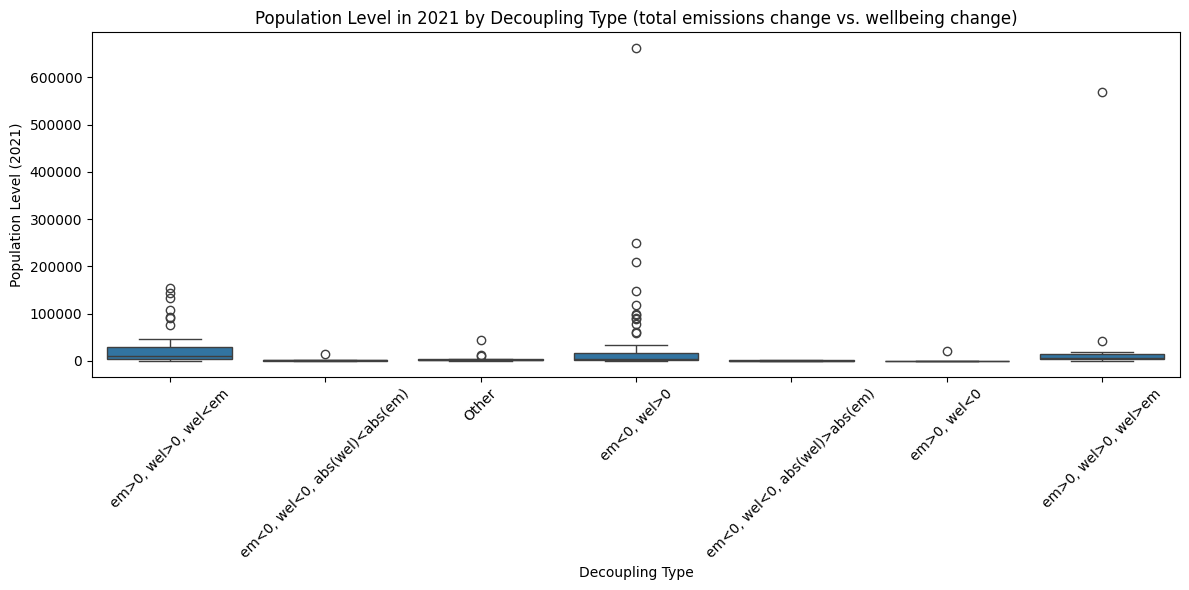

In [203]:
import seaborn as sns

#plot population level in 2021 vs whether the community is decoupling or not
plt.figure(figsize=(12, 6))
sns.boxplot(x='decoupling_type', y='Census Population 2021', data=final_analysis_data)
plt.title('Population Level in 2021 by Decoupling Type (total emissions change vs. wellbeing change)')
plt.xlabel('Decoupling Type')
plt.ylabel('Population Level (2021)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Next steps:
1) map the coupling vs decoupling of municipalities across BC
    a) find coordinates of each municipality
2) add transportation emissions to building emissions and redo analysis
    a) show road networks in the map and power line networks as well
3) segregate analysis by sector (industry vs residential)
4) try using emissions from 2007 with wellbeing from 2006?
5) compare the disaggregated components of the wellbeing index (e.g. income vs. education vs. housing) with the emissions 
6) compare coupling/decoupling with climate action plans in LGCAP and with climate impacts to see which communities are most vulnerable
7) use actual census data (e.g. mean income value for community, education level) and make a random forest model that predicts coupling/decoupling using the census data?
8) see if the poorest communities that had lowest wellbeing to start with are the ones going through negative decoupling
9) subtract wellbeing change from emissions change to have a number that measures the extent of decoupling, or use taipa equation


In [204]:
#get coordinates of each city in the bc-gazetteer-2024-06-13.csv file in the raw data folder
gazeteer = pd.read_csv(os.path.join('..','data','raw','bc-gazetteer-2024-06-13.csv'))
# Filter for communities in the final analysis data
gazeteer_filtered = gazeteer[gazeteer['Official Name'].isin(final_analysis_data['Community_Name']) & gazeteer['Feature Type'].isin(['City', 'Town', 'District Municipality', 'District Municipality (1)', 'Village (1)','Resort Municipality', 'Mountain Resort Municipality'])]


In [205]:
#print all unique official names in the gazeteer_filtered dataframe
print("Unique official names in gazeteer_filtered:")
print(gazeteer_filtered['Official Name'].unique())
#count unique official names
print(f"Total unique official names in gazeteer_filtered: {gazeteer_filtered['Official Name'].nunique()}")
#figure out which communities are missing coordinates
missing_coordinates = final_analysis_data[~final_analysis_data['Community_Name'].isin(gazeteer_filtered['Official Name'])]
print(f"Communities missing coordinates: {len(missing_coordinates)}")
print("Missing communities:")
for community in missing_coordinates['Community_Name'].unique():
    print(f"  {community}")

Unique official names in gazeteer_filtered:
['Abbotsford' 'Alert Bay' 'Anmore' 'Armstrong' 'Ashcroft' 'Barriere'
 'Belcarra' 'Bowen Island' 'Burnaby' 'Burns Lake' 'Cache Creek'
 'Campbell River' 'Canal Flats' 'Castlegar' 'Central Saanich' 'Chase'
 'Chetwynd' 'Chilliwack' 'Clearwater' 'Clinton' 'Coldstream' 'Colwood'
 'Comox' 'Coquitlam' 'Courtenay' 'Cranbrook' 'Creston' 'Cumberland'
 'Dawson Creek' 'Delta' 'Duncan' 'Elkford' 'Enderby' 'Esquimalt' 'Fernie'
 'Fort St. James' 'Fort St. John' 'Fraser Lake' 'Fruitvale' 'Gibsons'
 'Gold River' 'Golden' 'Grand Forks' 'Granisle' 'Greenwood'
 'Harrison Hot Springs' 'Hazelton' 'Highlands' 'Hope' 'Houston'
 "Hudson's Hope" 'Invermere' 'Kamloops' 'Kaslo' 'Kelowna' 'Kent'
 'Keremeos' 'Kimberley' 'Kitimat' 'Ladysmith' 'Lake Country'
 'Lake Cowichan' 'Langford' 'Lantzville' 'Lillooet' 'Lions Bay'
 'Logan Lake' 'Lumby' 'Lytton' 'Mackenzie' 'Maple Ridge' 'Masset'
 'McBride' 'Merritt' 'Metchosin' 'Midway' 'Mission' 'Montrose' 'Nakusp'
 'Nanaimo' 'Nelson

In [206]:
# Manual mapping for missing communities using both name and feature type
name_featuretype_corrections = {
    "Langley City": ("Langley", "City"),
    "Langley Township": ("Langley", "District Municipality (1)"),
    "North Vancouver City": ("North Vancouver", "City"),
    "North Vancouver District": ("North Vancouver", "District Municipality (1)"),
    "One Hundred Mile House": ("100 Mile House", "District Municipality (1)"),
    "Sun Peaks Mountain Resort": ("Sun Peaks", "Mountain Resort Municipality"),
    "West Kelowna": ("West Kelowna, City of", "City"),
    "Queen Charlotte": ("Queen Charlotte", "Post Office"),
}

missing_coords = []
for community, (gaz_name, feature_type) in name_featuretype_corrections.items():
    if feature_type:
        match = gazeteer[(gazeteer['Official Name'].str.lower() == gaz_name.lower()) &
                         (gazeteer['Feature Type'].str.lower() == feature_type.lower())]
    else:
        match = gazeteer[gazeteer['Official Name'].str.lower() == gaz_name.lower()]
    if not match.empty:
        feature_type = match.iloc[0]['Feature Type']
        lat = match.iloc[0]['LatDD']
        lon = match.iloc[0]['LongDD']
        datum = match.iloc[0]['Datum']
        missing_coords.append({'Official Name': community, 'Feature Type': feature_type, 'Datum': datum, 'LatDD': lat, 'LongDD': lon})
    else:
        print(f"Not found in gazeteer: {community} -> {gaz_name} ({feature_type})")

missing_coords_df = pd.DataFrame(missing_coords)
print(missing_coords_df)

               Official Name                  Feature Type  Datum      LatDD  \
0               Langley City                          City  WGS84  49.102500   
1           Langley Township     District Municipality (1)  WGS84  49.120278   
2       North Vancouver City                          City  WGS84  49.320556   
3   North Vancouver District     District Municipality (1)  WGS84  49.336111   
4     One Hundred Mile House     District Municipality (1)  WGS84  51.642778   
5  Sun Peaks Mountain Resort  Mountain Resort Municipality  WGS84  50.884444   
6               West Kelowna                          City  WGS84  49.830000   
7            Queen Charlotte                   Post Office  WGS84  53.253878   

       LongDD  
0 -122.658056  
1 -122.659722  
2 -123.073889  
3 -123.078056  
4 -121.295556  
5 -119.879444  
6 -119.628611  
7 -132.086418  


In [207]:
#add missing communities to gazeteer_filtered
gazeteer_filtered = pd.concat([gazeteer_filtered, missing_coords_df]).reset_index(drop=True)
gazeteer_filtered.head()
#gazeteer_filtered.tail(20)



,Official Name,Feature Type,Feature Type Code,Mapsheet,Latitude,Longitude,Datum,LatDD,LongDD
0,Abbotsford,City,1.0,92G/1,49 03 07 N,122 19 45 W,WGS84,49.052222,-122.329167
1,Alert Bay,Village (1),3.0,92L/10,50 35 01 N,126 55 40 W,WGS84,50.583889,-126.927778
2,Anmore,Village (1),3.0,92G/7,49 18 51 N,122 51 23 W,WGS84,49.314444,-122.856389
3,Armstrong,City,1.0,82L/6,50 26 53 N,119 11 48 W,WGS84,50.448333,-119.196667
4,Ashcroft,Village (1),3.0,92I/11,50 43 16 N,121 17 00 W,WGS84,50.721389,-121.283611


In [208]:
gazeteer_filtered.tail(20)


,Official Name,Feature Type,Feature Type Code,Mapsheet,Latitude,Longitude,Datum,LatDD,LongDD
139,Vancouver,City,1.0,92G/6,49 15 39 N,123 06 50 W,WGS84,49.261111,-123.113889
140,Vanderhoof,District Municipality (1),35.0,93K/1,54 01 02 N,124 00 26 W,WGS84,54.017500,-124.007500
141,Vernon,City,1.0,82L/6,50 15 56 N,119 16 18 W,WGS84,50.265833,-119.271667
142,Victoria,City,1.0,92B/6,48 25 41 N,123 21 52 W,WGS84,48.428333,-123.364722
143,View Royal,Town,2.0,92B/6,48 27 06 N,123 26 03 W,WGS84,48.451944,-123.434167
144,Warfield,Village (1),3.0,82F/4,49 05 38 N,117 44 57 W,WGS84,49.094167,-117.749167
145,Wells,District Municipality (1),35.0,93H/4,53 06 15 N,121 34 21 W,WGS84,53.104444,-121.572500
146,West Vancouver,District Municipality (1),35.0,92G/6,49 19 51 N,123 09 34 W,WGS84,49.331111,-123.159722
147,Whistler,Resort Municipality,16.0,92J/2,50 07 01 N,122 57 16 W,WGS84,50.117222,-122.954722
148,White Rock,City,1.0,92G/2,49 01 24 N,122 47 53 W,WGS84,49.023611,-122.798333


In [209]:

#check if the gazeteer_filtered dataframe has all the communities from final_analysis_data
print(f"Total communities in final_analysis_data: {len(final_analysis_data['Community_Name'].unique())}")
print(f"Total communities in gazeteer_filtered: {len(gazeteer_filtered['Official Name'].unique())}")
missing_communities =  set(gazeteer_filtered['Official Name'].unique()) - set(final_analysis_data['Community_Name'].unique())
print(f"Missing communities in gazeteer_filtered: {len(missing_communities)}")
if missing_communities:
    print("Missing communities:")
    for community in missing_communities:
        print(f"  {community}")

Total communities in final_analysis_data: 159
Total communities in gazeteer_filtered: 159
Missing communities in gazeteer_filtered: 0


In [210]:
#find duplicates
duplicates = gazeteer_filtered[gazeteer_filtered.duplicated(subset=['Official Name'], keep=False)]
print(f"Total duplicates found: {len(duplicates)}")
if not duplicates.empty:
    print("Duplicate entries:")
    for index, row in duplicates.iterrows():
        print(f"  {row['Official Name']} (Index: {index})")


Total duplicates found: 0


In [211]:
#extract official name, feature type, datum, latitude and longitude from gazeteer_filtered
gazeteer_final = gazeteer_filtered[['Official Name', 'Feature Type', 'Datum', 'LatDD', 'LongDD']].copy()
gazeteer_final.rename(columns={
    'Official Name': 'Community_Name',
    'Feature Type': 'Feature_Type',
    'Datum': 'Datum',
    'LatDD': 'Latitude',
    'LongDD': 'Longitude'
}, inplace=True)
# Save the gazeteer_final dataframe to a CSV file in the processed data folder
gazeteer_final.to_csv(os.path.join('..', 'data', 'processed', 'gazeteer_final.csv'), index=False)

In [212]:
gazeteer_final.tail(20)

,Community_Name,Feature_Type,Datum,Latitude,Longitude
139,Vancouver,City,WGS84,49.261111,-123.113889
140,Vanderhoof,District Municipality (1),WGS84,54.017500,-124.007500
141,Vernon,City,WGS84,50.265833,-119.271667
142,Victoria,City,WGS84,48.428333,-123.364722
143,View Royal,Town,WGS84,48.451944,-123.434167
144,Warfield,Village (1),WGS84,49.094167,-117.749167
145,Wells,District Municipality (1),WGS84,53.104444,-121.572500
146,West Vancouver,District Municipality (1),WGS84,49.331111,-123.159722
147,Whistler,Resort Municipality,WGS84,50.117222,-122.954722
148,White Rock,City,WGS84,49.023611,-122.798333


In [213]:
#merge the gazeteer data with the final_analysis_data
final_analysis_data_with_coords = pd.merge(final_analysis_data, gazeteer_final, on='Community_Name')
# Save the final analysis data with coordinates to a CSV file in the processed data folder
final_analysis_data_with_coords.to_csv(os.path.join('..', 'data', 'processed', 'final_analysis_data_with_coords.csv'), index=False)
# Display the final analysis data with coordinates
print("Final analysis data with coordinates:")
print(final_analysis_data_with_coords.head())

Final analysis data with coordinates:
  Community_Name  2016 EMISSIONS NET IMPORTS TCO2e  \
0     Abbotsford                     926180.582000   
1      Alert Bay                       1602.705601   
2         Anmore                      11972.111512   
3      Armstrong                      36938.412983   
4       Ashcroft                      19076.397754   

   2021 EMISSIONS NET IMPORTS TCO2e  emissions_percent_change  CWB 2016  \
0                      1.045921e+06                 12.928395      79.0   
1                      1.271113e+03                -20.689535      82.0   
2                      1.134648e+04                 -5.225766      88.0   
3                      3.417424e+04                 -7.483200      79.0   
4                      1.899236e+04                 -0.440552      77.0   

   Income 2016  Education 2016  Housing 2016  Labour Force Activity 2016  \
0         74.0            61.0          94.0                        87.0   
1         76.0            68.0    

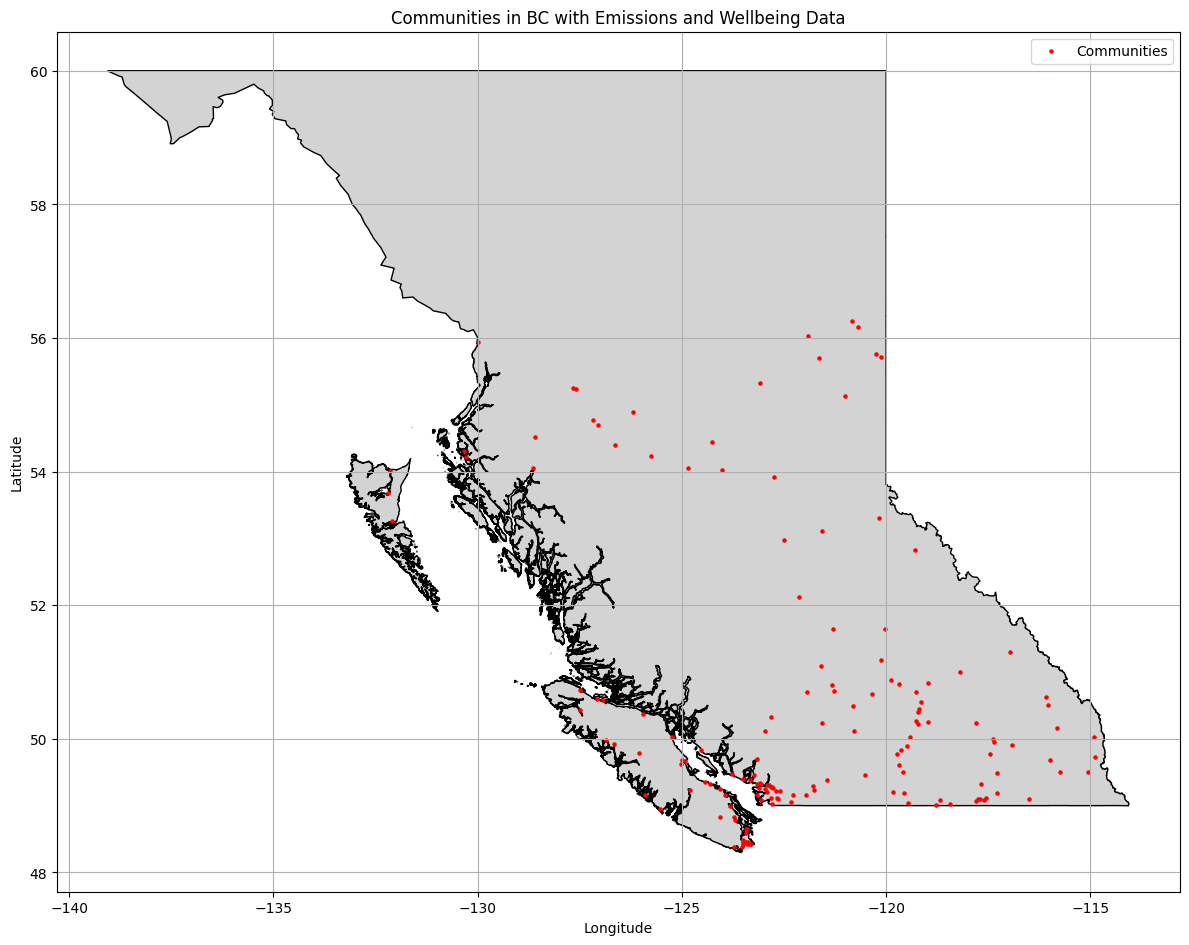

In [214]:
#plot the final analysis data with coordinates on a map of BC, with shapefile located in the raw dataset subfolder BC_Boundary as BC_Boundary.shp
import geopandas as gpd
# Load the shapefile for BC boundaries
bc_boundaries = gpd.read_file(os.path.join('..', 'data', 'raw', 'BC_Boundary', 'BC_Boundary.shp'))
# Convert the final analysis data with coordinates to a GeoDataFrame
final_analysis_gdf = gpd.GeoDataFrame(
    final_analysis_data_with_coords,
    geometry=gpd.points_from_xy(final_analysis_data_with_coords['Longitude'], final_analysis_data_with_coords['Latitude']),
    crs='EPSG:4326'  # WGS84 coordinate system
)

# Plot the BC boundaries and the final analysis data points
plt.figure(figsize=(12, 12))
bc_boundaries.plot(ax=plt.gca(), color='lightgrey', edgecolor='black')
final_analysis_gdf.plot(ax=plt.gca(), marker='o', color='red', markersize=5, label='Communities')
plt.title('Communities in BC with Emissions and Wellbeing Data')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


<Axes: >

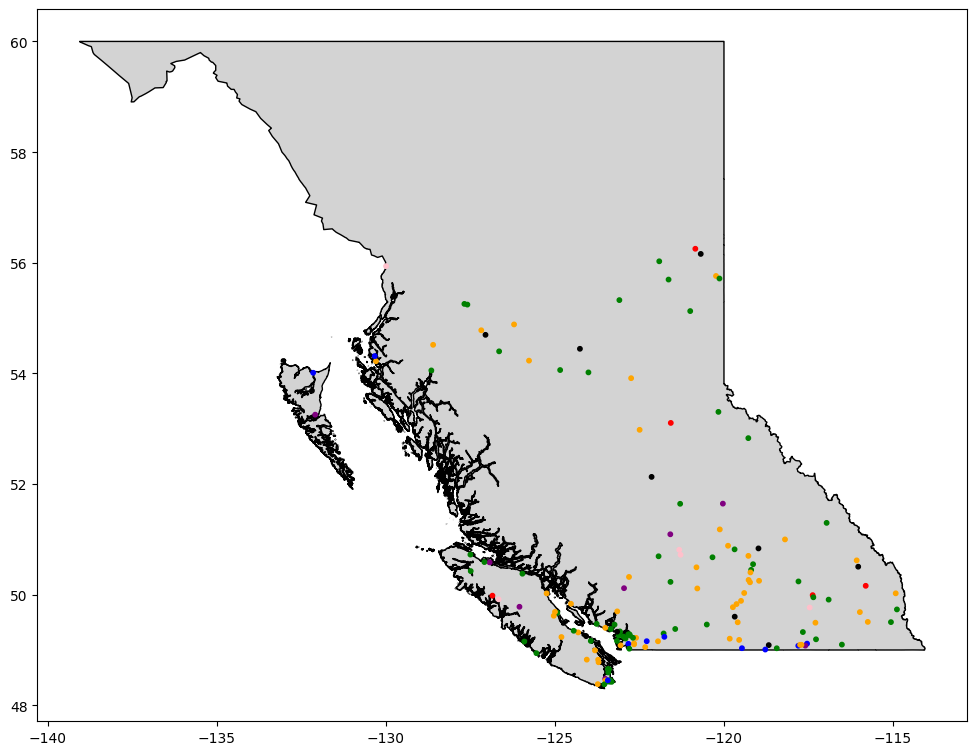

In [215]:
#plot which communities are decoupling or not on the map
plt.figure(figsize=(12, 12))
bc_boundaries.plot(ax=plt.gca(), color='lightgrey', edgecolor='black')
# Create a color map for decoupling types
decoupling_colors = {
    'em<0, wel>0': 'green',
    'em>0, wel>0, wel>em': 'blue',
    'em>0, wel>0, wel<em': 'orange',
    'em<0, wel<0, abs(wel)<abs(em)': 'purple',
    'em<0, wel<0, abs(wel)>abs(em)': 'pink',
    'em>0, wel<0': 'red',
    'Other': 'black'  # Default color for any other cases
}


# Map decoupling types to colors
final_analysis_gdf['color'] = final_analysis_gdf['decoupling_type'].map(decoupling_colors)
# Plot communities with colors based on decoupling type
final_analysis_gdf.plot(ax=plt.gca(), marker='o', color=final_analysis_gdf['color'], markersize=10, label='Communities')


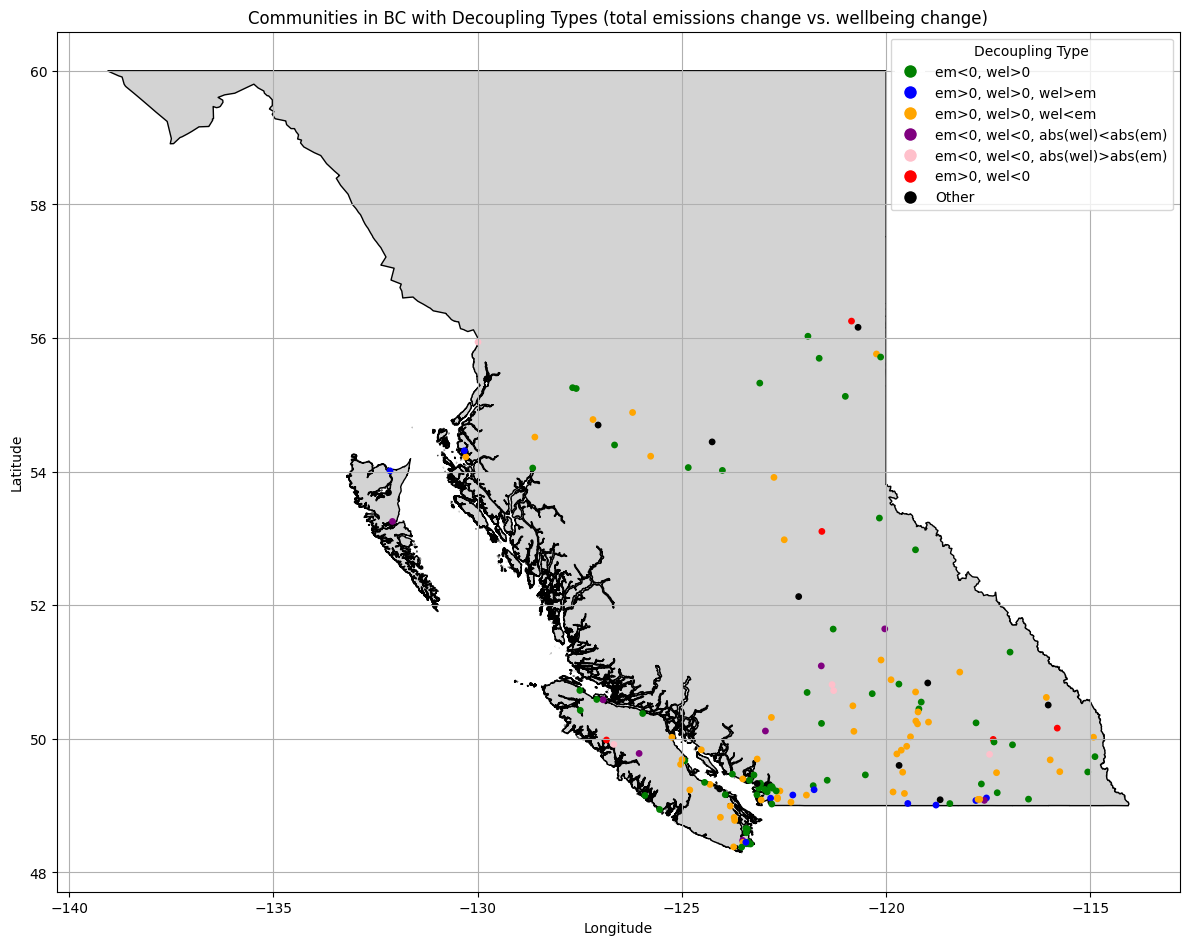

In [216]:
plt.figure(figsize=(12, 12))
bc_boundaries.plot(ax=plt.gca(), color='lightgrey', edgecolor='black')
#plot the map with legend showing each color based on decoupling type
final_analysis_gdf.plot(ax=plt.gca(), marker='o', color=final_analysis_gdf['color'], markersize=15, label='Communities')
# Create a custom legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label) for label, color in decoupling_colors.items()]
plt.legend(handles=handles, title='Decoupling Type', loc='upper right')

plt.title('Communities in BC with Decoupling Types (total emissions change vs. wellbeing change)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid()
plt.tight_layout()
plt.show()